<a href="https://colab.research.google.com/github/Sanathcharan/Data-Science-ExcelR/blob/main/Crossvalidation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv('advertising.csv')
df

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,27-03-2016 00:53,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,04-04-2016 01:39,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,13-03-2016 20:35,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,10-01-2016 02:31,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,03-06-2016 03:36,0
...,...,...,...,...,...,...,...,...,...,...
995,72.97,30,71384.57,208.58,Fundamental modular algorithm,Duffystad,1,Lebanon,11-02-2016 21:49,1
996,51.30,45,67782.17,134.42,Grass-roots cohesive monitoring,New Darlene,1,Bosnia and Herzegovina,22-04-2016 02:07,1
997,51.63,51,42415.72,120.37,Expanded intangible solution,South Jessica,1,Mongolia,01-02-2016 17:24,1
998,55.55,19,41920.79,187.95,Proactive bandwidth-monitored policy,West Steven,0,Guatemala,24-03-2016 02:35,0


In [ ]:
df.shape

(1000, 10)

In [ ]:
df.size

10000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [ ]:
df.drop(columns=['Ad Topic Line','City','Country','Timestamp'],inplace=True)

In [ ]:
df.isnull().sum()

,0
Daily Time Spent on Site,0
Age,0
Area Income,0
Daily Internet Usage,0
Male,0
Clicked on Ad,0


In [ ]:
df.duplicated().sum()

np.int64(0)

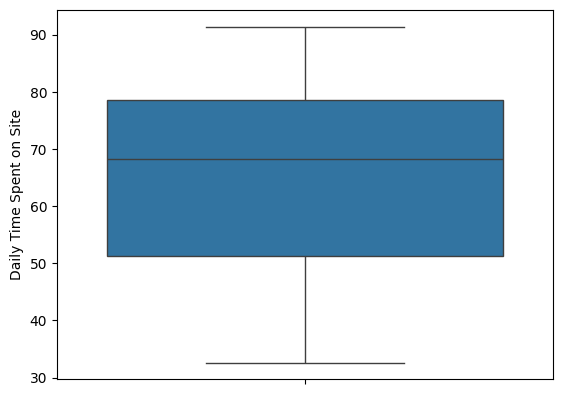

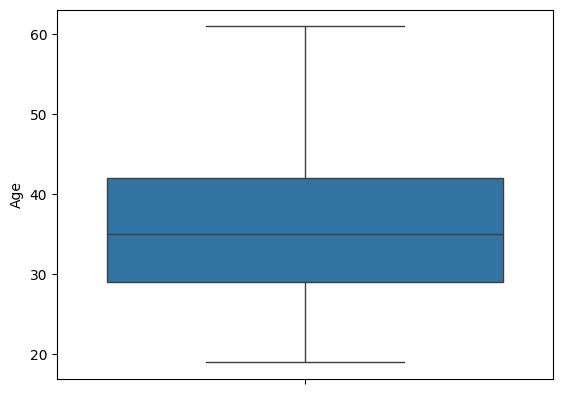

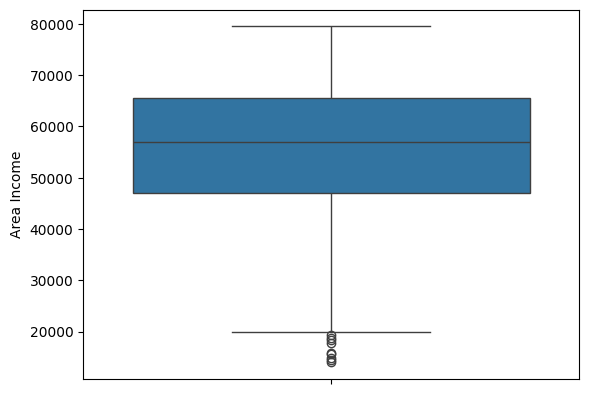

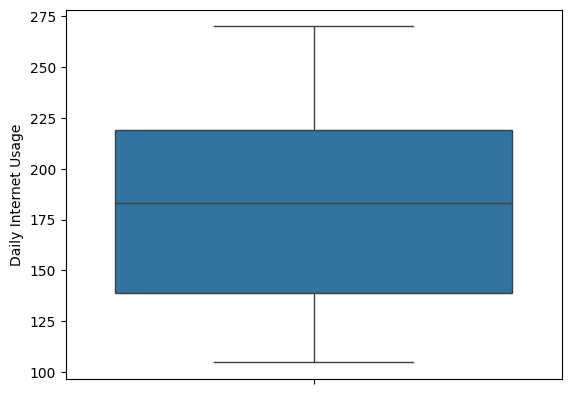

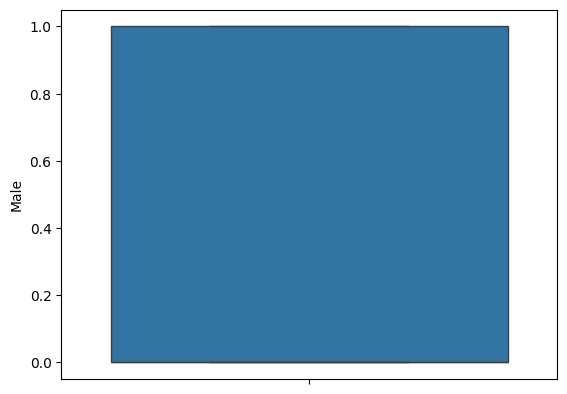

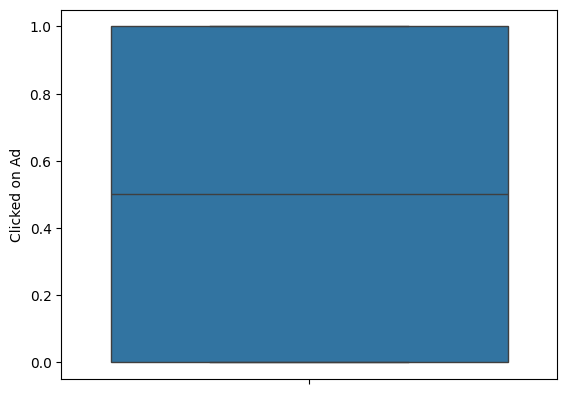

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  sns.boxplot(df[i])
  plt.show()

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  upper=q3+1.5*iqr
  lower=q1-1.5*iqr
  df[i]=df[i].clip(lower,upper)

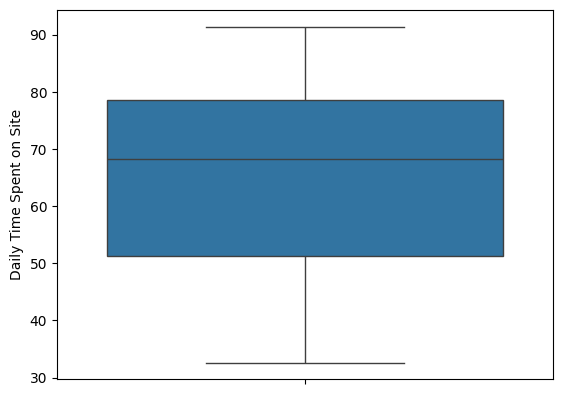

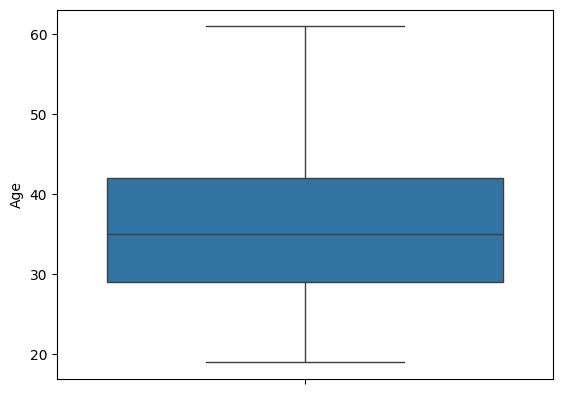

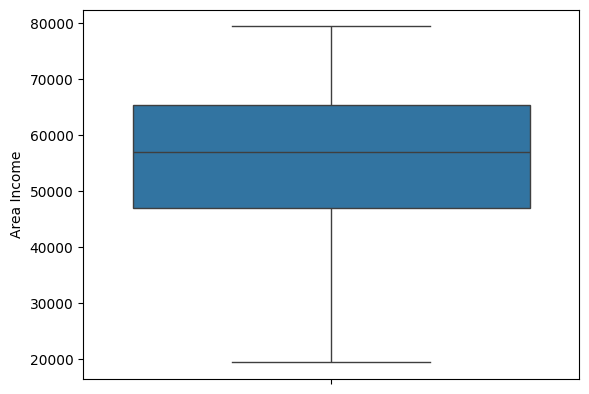

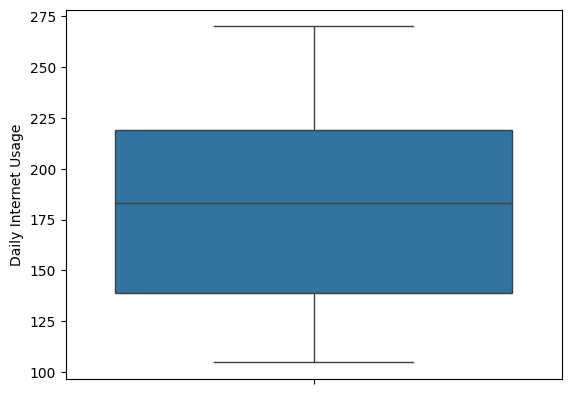

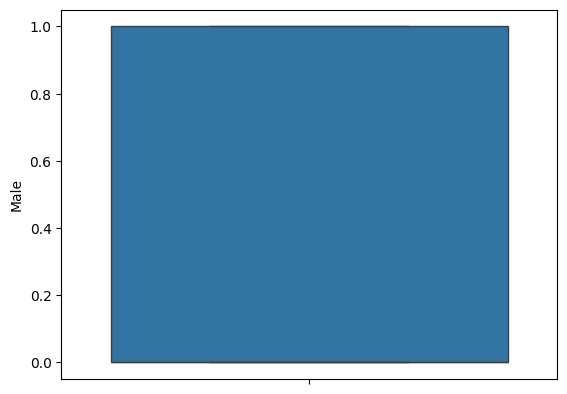

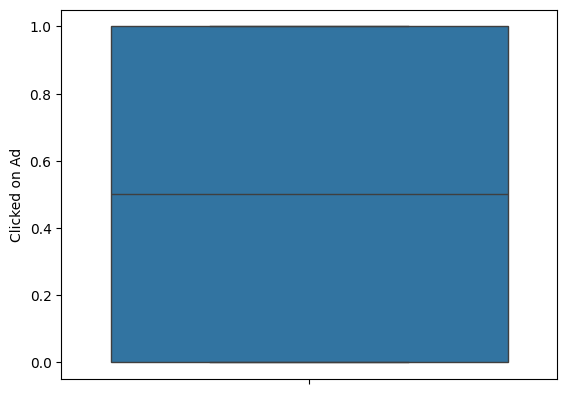

In [ ]:
for i in df.select_dtypes(include=['int','float']).columns:
  sns.boxplot(df[i])
  plt.show()

In [ ]:
x=df.drop(columns='Clicked on Ad')
y=df['Clicked on Ad']

In [ ]:
# hold out method
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=55)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
pred=lr.predict(x_test)
from sklearn.metrics import accuracy_score,classification_report
print("Accuracy of Test Data: ",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

NameError: name 'x_train' is not defined

In [ ]:
# shuffle split
from sklearn.model_selection import ShuffleSplit,StratifiedShuffleSplit,KFold,cross_validate
shuffle=ShuffleSplit(n_splits=5,test_size=0.2,random_state=55)
cross_validate(lr,x,y,scoring=['accuracy'],cv=shuffle,return_train_score=True)

{'fit_time': array([0.08080125, 0.40091443, 0.25661898, 0.05381775, 0.04905009]),
 'score_time': array([0.01331353, 0.01966381, 0.00535321, 0.01082945, 0.00341201]),
 'test_accuracy': array([0.885, 0.955, 0.915, 0.88 , 0.865]),
 'train_accuracy': array([0.895  , 0.9275 , 0.90125, 0.89875, 0.915  ])}

In [ ]:
cv=cross_validate(lr,x,y,scoring=['accuracy'],cv=shuffle,return_train_score=True)
print("Test Accuracy: ",cv['test_accuracy'].mean())
print("Train Accuracy: ",cv['train_accuracy'].mean())

Test Accuracy:  0.9
Train Accuracy:  0.9075


In [ ]:
# stratified shuffle split
str_shuffle=StratifiedShuffleSplit(n_splits=5,test_size=0.2,random_state=55)
cv=cross_validate(lr,x,y,scoring=['accuracy'],cv=str_shuffle,return_train_score=True)
print("Test Accuracy: ",cv['test_accuracy'].mean())
print("Train Accuracy: ",cv['train_accuracy'].mean())

Test Accuracy:  0.951
Train Accuracy:  0.94725


In [ ]:
# K fold method 1
cv=cross_validate(lr,x,y,scoring=['accuracy'],cv=5,return_train_score=True)
print("Test Accuracy: ",cv['test_accuracy'].mean())
print("Train Accuracy: ",cv['train_accuracy'].mean())

Test Accuracy:  0.9109999999999999
Train Accuracy:  0.91275


In [ ]:
# k fold method 2
kfold=KFold(n_splits=5,shuffle=True,random_state=50)
cv=cross_validate(lr,x,y,scoring=['accuracy'],cv=kfold,return_train_score=True)
print("Test Accuracy: ",cv['test_accuracy'].mean())
print("Train Accuracy: ",cv['train_accuracy'].mean())

Test Accuracy:  0.9199999999999999
Train Accuracy:  0.9235
